# Step 3: MSM construction and validation

In [1]:
%load_ext autoreload
%autoreload 2 

data_folder = "../data/"

import os
import numpy as np
import pandas as pd

# ----------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import LogLocator
import plotting_utils as pu
from matplotlib.colors import TwoSlopeNorm
import matplotlib as mpl
# ----------------------------------------


# ----------------------------------------
from tqdm.notebook import tqdm  # progress bar 
from deeptime.clustering import KMeans
#import networkx as nx # graph visualization of MSM microstates and macrostates model
# ----------------------------------------


# ----------------------------------------
from deeptime.markov import TransitionCountEstimator
from deeptime.markov.msm import MaximumLikelihoodMSM
# ----------------------------------------

---
#### Reloading reduced data

In [2]:
tica_lag = 100 # lag time for TICA in frames, 1000 frames = 200 nanoseconds
tica_dim_distances = 5
tica_dim_dihedrals = 7
pca_dim_distances = 5
pca_dim_dihedrals = 5


tica_dihedrals = np.load(f"../intermediate_outputs/dimred/tica_lag_{tica_lag}_dim_{tica_dim_dihedrals}_dihedrals.npy")
pca_dihedrals = np.load(f"../intermediate_outputs/dimred/pca_dim_{pca_dim_dihedrals}_dihedrals.npy")
tica_distances = np.load(f"../intermediate_outputs/dimred/tica_lag_{tica_lag}_dim_{tica_dim_distances}_distances.npy")
pca_distances = np.load(f"../intermediate_outputs/dimred/pca_dim_{pca_dim_distances}_distances.npy")


trajectories = [tica_distances, pca_distances, tica_dihedrals, pca_dihedrals]
trajectories_labels = ["tica_distances", "pca_distances", "tica_dihedrals", "pca_dihedrals"]


total_time_micros = 305
time_step_micros =  total_time_micros / 1526041 #/ distances.shape[0]
time_step_nanos = time_step_micros * 10**3
print("Time step (microseconds)", time_step_micros) # 2x10^-4 microseconds
print("Time step (nanoseconds)", time_step_micros * 10**3) # 0.2 nanoseconds
print("Time step (picoseconds)", time_step_micros * 10**6) # 200 picoseconds
one_microsecond_in_frames = int(1 / time_step_micros)
print("One microsecond in frames", one_microsecond_in_frames) # 5000 frames

Time step (microseconds) 0.00019986356854108112
Time step (nanoseconds) 0.19986356854108112
Time step (picoseconds) 199.86356854108112
One microsecond in frames 5003


Performing kmeans clustering + msm transition matrix estimation + implied timescales test

In [3]:
kcluster_list = [50]

run_kmeans = False # avoid rerunning accidentantly as it takes a long time

if run_kmeans:

    for n_clusters in kcluster_list:
        print(f"Running KMeans with {n_clusters} clusters...")
        kmeans = KMeans(
            n_clusters=n_clusters,
            init_strategy='kmeans++',
            max_iter=200,
            fixed_seed=13,
            n_jobs=8,
            progress=tqdm
        )
        for i, traj in enumerate(trajectories):
            traj_name = trajectories_labels[i]
            kmeans.fit(traj)
            discretized_trajectories = kmeans.transform(traj)
            model = kmeans.fetch_model() # fetches the latest model, containing all important information
            plt.loglog(model.inertias)
            plt.xlabel("iteration")
            plt.ylabel("inertia")
            plt.title("KMeans with uniform initialization inertia during training")

            np.savez(f"../intermediate_outputs/kmeans_plusplus/{n_clusters}clusters_{traj_name}", traj = discretized_trajectories, centers = model.cluster_centers)

Compute implied timescales, size of largest connected component and size of the active population at varying lagtime

In [4]:
lagtimes_ns = np.arange(1, 100, 5) # lag times in nanoseconds
lagtimes = (lagtimes_ns / time_step_nanos).astype(int) # lag times in frames (10 frames = 2 nanoseconds, 5000 frames = 1 microsecond)
#lagtimes = np.arange(100, 2500, 100) # lag times in frames (10 frames = 2 nanoseconds, 5000 frames = 1 microsecond)

kcluster_list = [30, 50, 100]

df = pd.DataFrame(
    index=pd.MultiIndex.from_product(
        [trajectories_labels, kcluster_list, lagtimes],
        names=["Trajectory", "N_clusters", "Lag"]
    ),
    columns=[f"Timescale_{i}" for i in range(1, 11)],
    dtype=float
)

for n_clusters in kcluster_list:
    for traj_name in trajectories_labels:

        data = np.load(f"../intermediate_outputs/kmeans_plusplus/{n_clusters}clusters_{traj_name}.npz")
        dtraj = data["traj"]
        populated_clusters = np.unique(dtraj)

        for lag in lagtimes:
            tce = TransitionCountEstimator(
                lagtime=lag,
                count_mode="sliding-effective"
            )
            C = tce.fit(dtraj).fetch_model()
            submodel = C.submodel_largest(connectivity_threshold=1., directed=True)
            active_frames = submodel.transform_discrete_trajectories_to_submodel(dtraj) != -1
            active_population = np.sum(active_frames) / len(dtraj)
            df.loc[(traj_name, n_clusters, lag), "active_pop"] = active_population # fraction of total population in active states
            df.loc[(traj_name, n_clusters, lag), "llc"] = submodel.n_states/n_clusters # size of largest connected component (llc) as a fraction of total number of clusters

            msm = MaximumLikelihoodMSM(reversible = True).fit(C).fetch_model()
            its = msm.timescales(k=10)
            cols = [f"Timescale_{i}" for i in range(1, len(its) + 1)]
            df.loc[(traj_name, n_clusters, lag), cols] = its
            df.to_csv("../intermediate_outputs/implied_timescales.csv", mode = "w", header = True)
            df.head()

/var/folders/vk/kftm8379123bsmwrdp8l0xr00000gn/T/ipykernel_50732/3147418491.py:32: PerformanceWarning: indexing past lexsort depth may impact performance.
  df.loc[(traj_name, n_clusters, lag), "active_pop"] = active_population # fraction of total population in active states
/var/folders/vk/kftm8379123bsmwrdp8l0xr00000gn/T/ipykernel_50732/3147418491.py:33: PerformanceWarning: indexing past lexsort depth may impact performance.
  df.loc[(traj_name, n_clusters, lag), "llc"] = submodel.n_states/n_clusters # size of largest connected component (llc) as a fraction of total number of clusters
/var/folders/vk/kftm8379123bsmwrdp8l0xr00000gn/T/ipykernel_50732/3147418491.py:32: PerformanceWarning: indexing past lexsort depth may impact performance.
  df.loc[(traj_name, n_clusters, lag), "active_pop"] = active_population # fraction of total population in active states
/var/folders/vk/kftm8379123bsmwrdp8l0xr00000gn/T/ipykernel_50732/3147418491.py:33: PerformanceWarning: indexing past lexsort depth

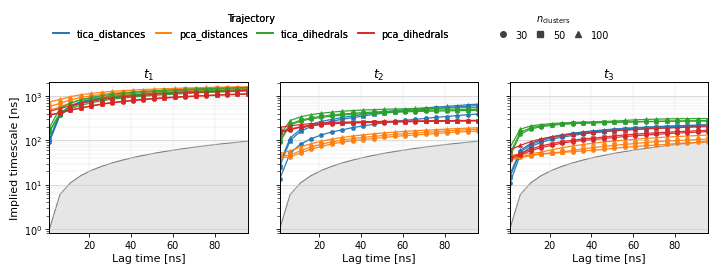

In [5]:
from matplotlib.ticker import LogLocator, NullFormatter

# --------------------------------
# Report-style settings
# --------------------------------
plt.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.minor.width": 0.45,
    "ytick.minor.width": 0.45,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
    "savefig.dpi": 300,
})

# --------------------------------
# Load and clean data
# --------------------------------
df = pd.read_csv(
    "../intermediate_outputs/implied_timescales.csv",
    index_col=[0, 1, 2]
)

df.index.names = ["Trajectory", "N_clusters", "Lag"]

df = (
    df.reset_index()
      .drop_duplicates(
          subset=["Trajectory", "N_clusters", "Lag"],
          keep="last"
      )
)

# Convert lag and implied timescales to ns
df["Lag"] = df["Lag"].astype(float) * time_step_nanos

timescale_cols = [
    col for col in df.columns
    if col.startswith("Timescale_")
]

for col in timescale_cols:
    df[col] = df[col].astype(float) * time_step_nanos

# --------------------------------
# Plot settings
# --------------------------------
n_timescales_to_plot = 3

trajectories__ = list(df["Trajectory"].unique())
n_clusters_values = sorted(df["N_clusters"].unique())

# Encoding:
# color = trajectory
# marker = n_clusters
color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
traj_to_color = {
    traj: color_cycle[i % len(color_cycle)]
    for i, traj in enumerate(trajectories__)
}

markers = ["o", "s", "^", "D", "v", "P", "X", "*"]
cluster_to_marker = {
    n_clusters: markers[i % len(markers)]
    for i, n_clusters in enumerate(n_clusters_values)
}

# Lag values for diagonal reference
lag_values = np.sort(df["Lag"].unique())
lag_min = lag_values.min()
lag_max = lag_values.max()

# Positive finite values only for log-scale y limits
all_ts_values = df[
    [f"Timescale_{i}" for i in range(1, n_timescales_to_plot + 1)]
].to_numpy(dtype=float)

positive_ts = all_ts_values[np.isfinite(all_ts_values) & (all_ts_values > 0)]

ymin = max(0.8 * min(lag_min, positive_ts.min()), 1e-3)
ymax = 1.25 * positive_ts.max()

# --------------------------------
# Figure
# --------------------------------
fig, axs = plt.subplots(
    nrows=1,
    ncols=n_timescales_to_plot,
    figsize=(7.2, 2.6),
    sharex=True,
    sharey=True
)

if n_timescales_to_plot == 1:
    axs = np.array([axs])

for i, ax in enumerate(axs, start=1):

    # Unresolved region: t_i < tau
    ax.fill_between(
        lag_values,
        ymin,
        lag_values,
        color="0.90",
        zorder=0
    )

    # Reference line: t_i = tau
    ax.plot(
        lag_values,
        lag_values,
        color="0.45",
        lw=0.8,
        alpha=0.9,
        zorder=1
    )

    for traj in trajectories__:
        for n_clusters in n_clusters_values:

            sub = df[
                (df["Trajectory"] == traj)
                & (df["N_clusters"] == n_clusters)
            ].sort_values("Lag")

            if sub.empty:
                continue

            ycol = f"Timescale_{i}"

            ax.plot(
                sub["Lag"],
                sub[ycol],
                color=traj_to_color[traj],
                marker=cluster_to_marker[n_clusters],
                lw=0.9,
                ms=3.0,
                markeredgewidth=0.4,
                alpha=0.95,
                label=f"{traj}, {n_clusters}"
            )

    ax.set_title(rf"$t_{i}$", pad=3)
    ax.set_xlabel("Lag time [ns]", labelpad=2)

    ax.set_yscale("log")
    ax.set_xlim(lag_min, lag_max)
    ax.set_ylim(ymin, ymax)

    ax.yaxis.set_major_locator(LogLocator(base=10))
    ax.yaxis.set_minor_locator(
        LogLocator(base=10, subs=np.arange(2, 10) * 0.1)
    )
    ax.yaxis.set_minor_formatter(NullFormatter())

    ax.grid(axis="y", which="major", color="0.82", lw=0.55)
    ax.grid(axis="y", which="minor", color="0.90", lw=0.35)
    ax.grid(axis="x", which="major", color="0.90", lw=0.35)

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=7,
        width=0.6,
        length=3,
        pad=2
    )
    ax.tick_params(
        axis="both",
        which="minor",
        width=0.45,
        length=2
    )

    for spine in ax.spines.values():
        spine.set_linewidth(0.7)

axs[0].set_ylabel("Implied timescale [ns]", labelpad=3)

# --------------------------------
# Build clean two-part legend
# --------------------------------
trajectory_handles = [
    plt.Line2D(
        [0], [0],
        color=traj_to_color[traj],
        lw=1.2,
        label=str(traj)
    )
    for traj in trajectories__
]

cluster_handles = [
    plt.Line2D(
        [0], [0],
        color="0.25",
        marker=cluster_to_marker[n_clusters],
        lw=0,
        ms=4,
        label=str(n_clusters)
    )
    for n_clusters in n_clusters_values
]

legend_1 = fig.legend(
    handles=trajectory_handles,
    title="Trajectory",
    loc="upper center",
    bbox_to_anchor=(0.36, 1.08),
    ncol=min(len(trajectories__), 4),
    frameon=False,
    fontsize=7,
    title_fontsize=7,
    handlelength=1.6,
    columnspacing=1.0
)

legend_2 = fig.legend(
    handles=cluster_handles,
    title=r"$n_\mathrm{clusters}$",
    loc="upper center",
    bbox_to_anchor=(0.78, 1.08),
    ncol=min(len(n_clusters_values), 6),
    frameon=False,
    fontsize=7,
    title_fontsize=7,
    handlelength=1.0,
    columnspacing=0.8
)

fig.add_artist(legend_1)

fig.subplots_adjust(
    left=0.08,
    right=0.995,
    bottom=0.20,
    top=0.78,
    wspace=0.16
)

fig.savefig(
    "../output_figures/implied_timescales_report.pdf",
    bbox_inches="tight"
)

fig.savefig(
    "../output_figures/implied_timescales_report.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

/var/folders/vk/kftm8379123bsmwrdp8l0xr00000gn/T/ipykernel_50732/3020052605.py:63: PerformanceWarning: indexing past lexsort depth may impact performance.
  sub = df.loc[(traj_name, n_clusters)].sort_index()


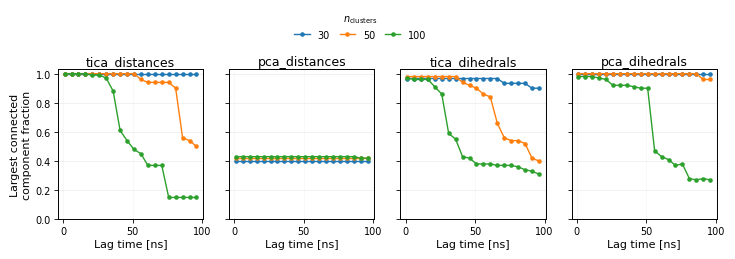

In [6]:
# --------------------------------
# Report-style settings
# --------------------------------
plt.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "savefig.dpi": 300,
})

# --------------------------------
# Input assumptions
# df has MultiIndex: (traj_name, n_clusters, lag)
# df has column: "llc"
# --------------------------------
df = pd.read_csv(
    "../intermediate_outputs/implied_timescales.csv",
    index_col=[0, 1, 2]
)

df.index.names = ["traj_name", "n_clusters", "lag"]
traj_names = list(df.index.get_level_values("traj_name").unique())
n_clusters_values = sorted(df.index.get_level_values("n_clusters").unique())

n_panels = len(traj_names)

# --------------------------------
# Figure size
# Good for one-column-wide row of panels in report.
# If n_panels = 4, this gives ~7.2 x 2.5 in.
# --------------------------------
fig_width = 7.2
fig_height = 2.5 if n_panels <= 4 else 3.0

fig, axs = plt.subplots(
    nrows=1,
    ncols=n_panels,
    figsize=(fig_width, fig_height),
    sharex=True,
    sharey=True
)

if n_panels == 1:
    axs = np.array([axs])

# --------------------------------
# Plot
# --------------------------------
for panel_id, (ax, traj_name) in enumerate(zip(axs, traj_names)):

    for n_clusters in n_clusters_values:

        # Skip missing combinations
        try:
            sub = df.loc[(traj_name, n_clusters)].sort_index()
        except KeyError:
            continue

        lag_time_ns = np.asarray(sub.index, dtype=float) * time_step_nanos

        ax.plot(
            lag_time_ns,
            sub["llc"].to_numpy(),
            marker="o",
            lw=1.0,
            ms=2.8,
            markeredgewidth=0.4,
            label=f"{n_clusters}"
        )

    ax.set_title(str(traj_name), pad=3)
    ax.set_xlabel("Lag time [ns]", labelpad=2)

    ax.grid(axis="y", alpha=0.25, lw=0.5)
    ax.grid(axis="x", alpha=0.15, lw=0.4)

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=7,
        width=0.6,
        length=3,
        pad=2
    )

    for spine in ax.spines.values():
        spine.set_linewidth(0.7)


axs[0].set_ylabel("Largest connected\ncomponent fraction", labelpad=3)

# If llc is a fraction, keep the same y-scale for all panels
axs[0].set_ylim(0.0, 1.03)

# --------------------------------
# Shared legend outside the panels
# --------------------------------
handles, labels = axs[-1].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title=r"$n_\mathrm{clusters}$",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=min(len(n_clusters_values), 6),
    frameon=False,
    fontsize=7,
    title_fontsize=7,
    handlelength=1.6,
    columnspacing=1.0
)

fig.subplots_adjust(
    left=0.08,
    right=0.995,
    bottom=0.22,
    top=0.82,
    wspace=0.18
)

fig.savefig(
    "../output_figures/largest_connected_component_vs_lag.pdf",
    bbox_inches="tight"
)

fig.savefig(
    "../output_figures/largest_connected_component_vs_lag.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

/var/folders/vk/kftm8379123bsmwrdp8l0xr00000gn/T/ipykernel_50732/2012956034.py:37: PerformanceWarning: indexing past lexsort depth may impact performance.
  sub = df.loc[(traj_name, n_clusters)].sort_index()


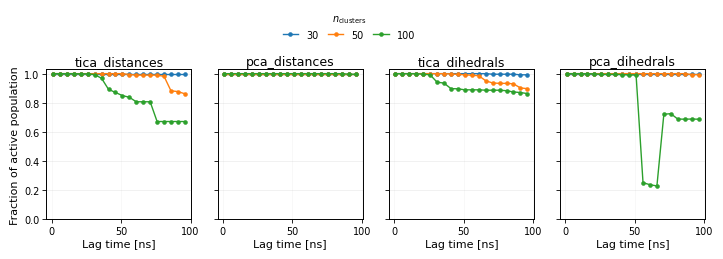

In [7]:
# Plot active population fraction vs lag time for each trajectory and n_clusters

df.index.names = ["traj_name", "n_clusters", "lag"]
traj_names = list(df.index.get_level_values("traj_name").unique())
n_clusters_values = sorted(df.index.get_level_values("n_clusters").unique())

n_panels = len(traj_names)

# --------------------------------
# Figure size
# Good for one-column-wide row of panels in report.
# If n_panels = 4, this gives ~7.2 x 2.5 in.
# --------------------------------
fig_width = 7.2
fig_height = 2.5 if n_panels <= 4 else 3.0

fig, axs = plt.subplots(
    nrows=1,
    ncols=n_panels,
    figsize=(fig_width, fig_height),
    sharex=True,
    sharey=True
)

if n_panels == 1:
    axs = np.array([axs])

# --------------------------------
# Plot
# --------------------------------
for panel_id, (ax, traj_name) in enumerate(zip(axs, traj_names)):

    for n_clusters in n_clusters_values:

        # Skip missing combinations
        try:
            sub = df.loc[(traj_name, n_clusters)].sort_index()
        except KeyError:
            continue

        lag_time_ns = np.asarray(sub.index, dtype=float) * time_step_nanos

        ax.plot(
            lag_time_ns,
            sub["active_pop"].to_numpy(),
            marker="o",
            lw=1.0,
            ms=2.8,
            markeredgewidth=0.4,
            label=f"{n_clusters}"
        )

    ax.set_title(str(traj_name), pad=3)
    ax.set_xlabel("Lag time [ns]", labelpad=2)

    ax.grid(axis="y", alpha=0.25, lw=0.5)
    ax.grid(axis="x", alpha=0.15, lw=0.4)

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=7,
        width=0.6,
        length=3,
        pad=2
    )

    for spine in ax.spines.values():
        spine.set_linewidth(0.7)


axs[0].set_ylabel("Fraction of active population", labelpad=3)

# If llc is a fraction, keep the same y-scale for all panels
axs[0].set_ylim(0.0, 1.03)

# --------------------------------
# Shared legend outside the panels
# --------------------------------
handles, labels = axs[-1].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title=r"$n_\mathrm{clusters}$",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=min(len(n_clusters_values), 6),
    frameon=False,
    fontsize=7,
    title_fontsize=7,
    handlelength=1.6,
    columnspacing=1.0
)

fig.subplots_adjust(
    left=0.08,
    right=0.995,
    bottom=0.22,
    top=0.82,
    wspace=0.18
)

fig.savefig(
    "../output_figures/active_population_vs_lag.pdf",
    bbox_inches="tight"
)

fig.savefig(
    "../output_figures/active_population_vs_lag.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

---

# Selected parameters:

In [8]:
MSM_LAG_NS = 50
MSM_LAG_FRAMES = int(MSM_LAG_NS / time_step_nanos) # 200 ns
print("MSM lag time in frames:", MSM_LAG_FRAMES)
N_CLUSTERS = 50
tce = TransitionCountEstimator(lagtime=MSM_LAG_FRAMES, count_mode="sliding-effective")

MSM lag time in frames: 250


Estimate MSMs at selected parameters

In [9]:
msm_dict = {}

#cluster_centers_dict = {} # cluster idx to microstate idx
micro_trajectory_dict = {} # traj -> micro traj
#clean_micro_trajectory_dict = {} # traj -> micro traj

for i, name in enumerate(trajectories_labels):
    data = np.load(f"../intermediate_outputs/kmeans_plusplus/{N_CLUSTERS}clusters_{name}.npz")
    dtraj = data["traj"].copy()


    C = tce.fit(dtraj).fetch_model()
    submodel = C.submodel_largest(directed=True)

    micro_trajectory_dict[name] = submodel.transform_discrete_trajectories_to_submodel(data["traj"])
    #assigned_frames = micro_trajectory_dict[name] != -1
    #active_population = np.sum(assigned_frames) / len(micro_trajectory_dict[name])
    #print(f"Active population for {name}: {active_population:.4f}")

    #np.save(f"../intermediate_outputs/microstate_trajs/{n_clusters}clusters_{MSM_LAG_FRAMES}lag_{name}_submodel.npy", micro_trajectory_dict[name])

    #clean_micro_trajectory_dict[name] = pu.clean_assignments(micro_trajectory_dict[name], max_dist= 100)

    msm = MaximumLikelihoodMSM(reversible = True).fit(submodel).fetch_model()
    msm_dict[name] = msm

In [10]:
for name, msm in msm_dict.items():
    print("Name: {}, active states: {}".format(name, msm.n_states))
    # Active population (fraction of total population in active states)

Name: tica_distances, active states: 50
Name: pca_distances, active states: 21
Name: tica_dihedrals, active states: 49
Name: pca_dihedrals, active states: 50


Plot cluster centers

# CK test 

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Skipping state set [2] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [3] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [4] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [7] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [10] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [12] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [13] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [16] due to error in estimation: Some row and corresponding column of the count matrix C have ze

  0%|          | 0/50 [00:00<?, ?it/s]

Skipping state set [39] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [44] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [80] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [39] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [44] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [80] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [39] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [44] due to error in estimation: Some row and corresponding column of the count matrix C hav

  0%|          | 0/50 [00:00<?, ?it/s]

Skipping state set [39] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [44] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [39] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [44] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [39] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [44] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [39] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [44] due to error in estimation: Some row and corresponding column of the count matrix C hav

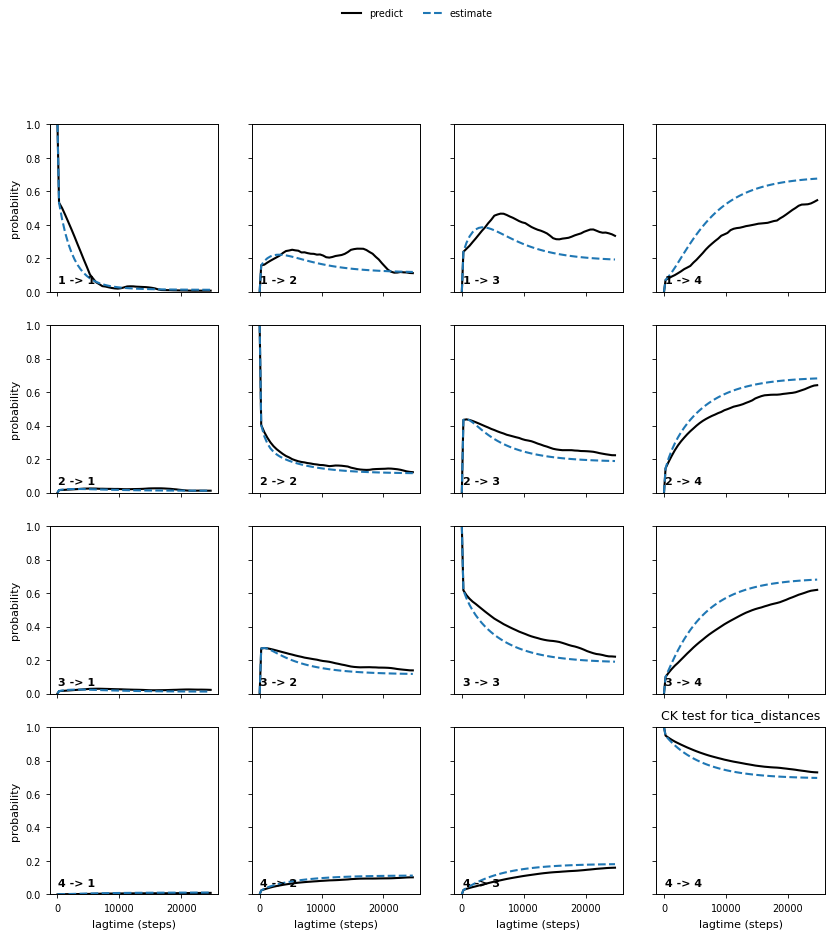

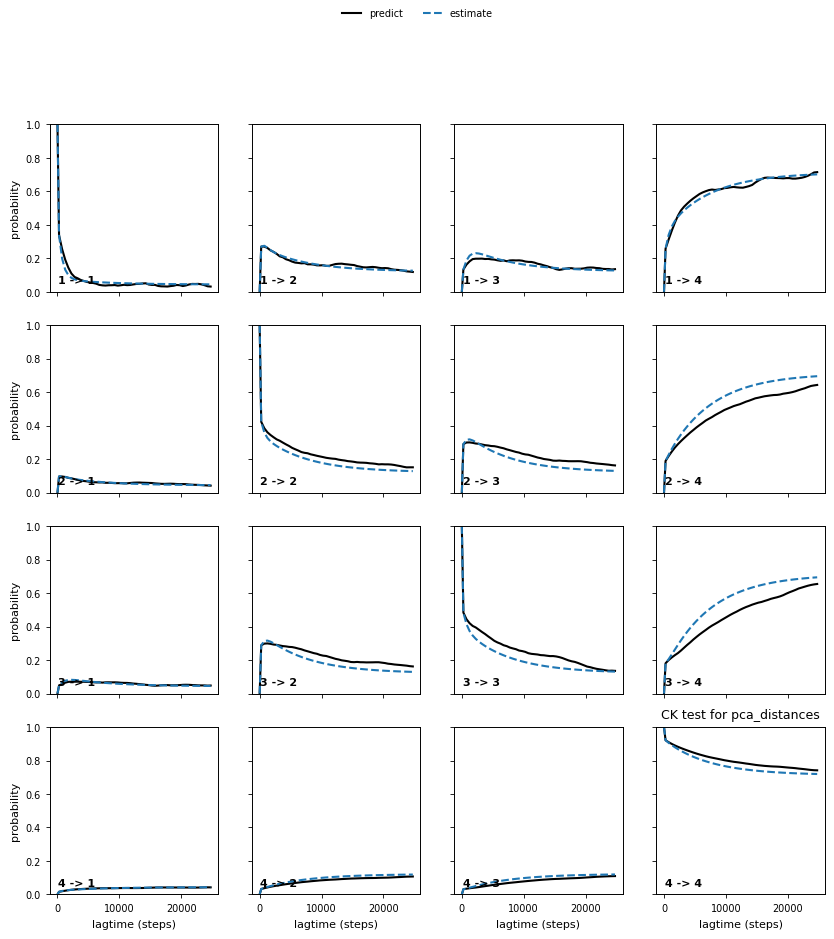

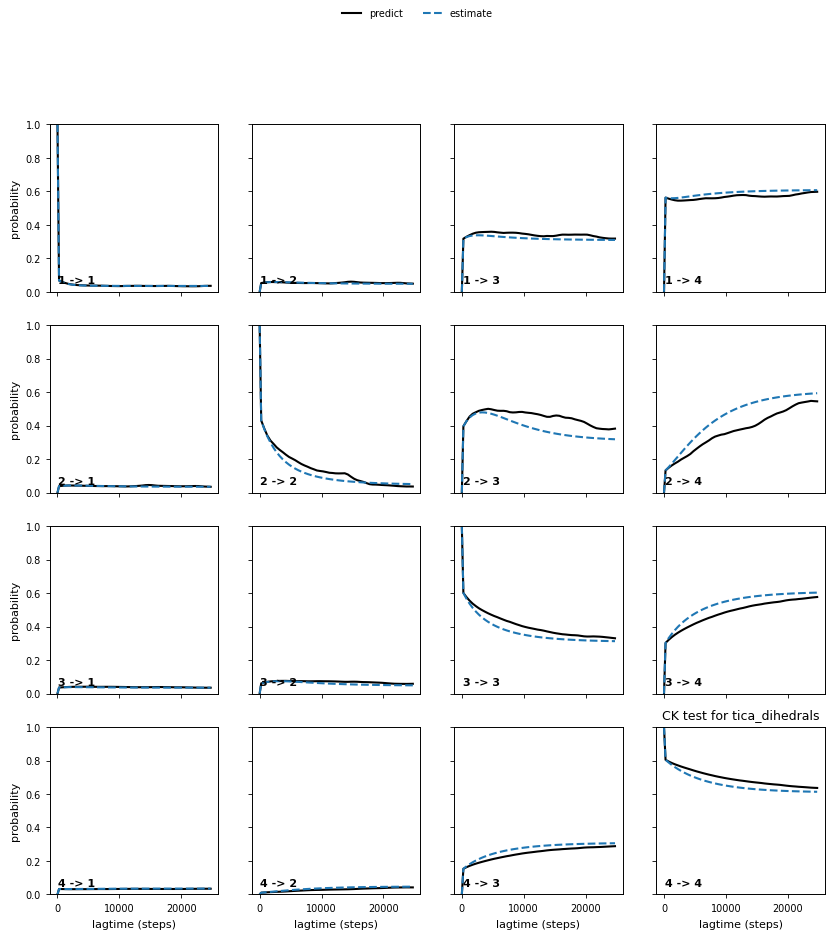

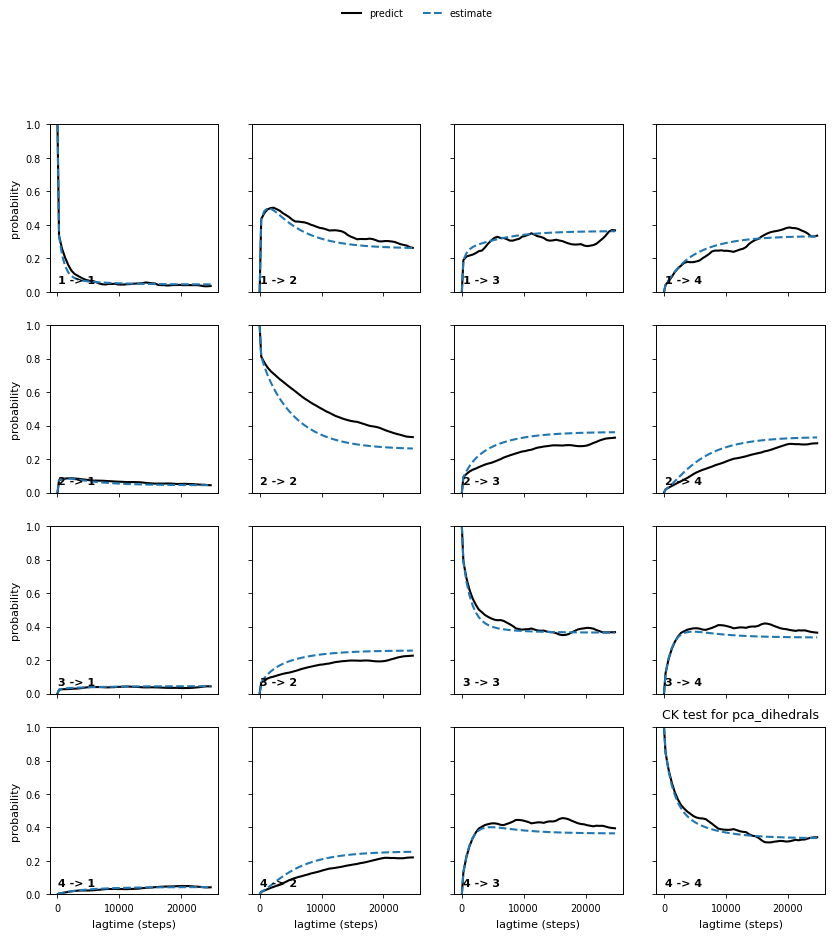

In [11]:
from deeptime.plots import plot_ck_test

lag_array = [MSM_LAG_FRAMES * i for i in range(1, 100, 2)] # lag times in frames


lagtime_models_dict = {}
for traj in trajectories_labels:
    data = np.load(f"../intermediate_outputs/kmeans_plusplus/{n_clusters}clusters_{traj}.npz")
    dtraj = data["traj"].copy()

    # estimate markov model for each lag time
    models = []
    for lag in tqdm(lag_array):
        tce = TransitionCountEstimator(
                    lagtime=lag,
                    count_mode="sliding-effective"
                )
        C = tce.fit(dtraj).fetch_model()
        msm = MaximumLikelihoodMSM(reversible = True).fit(C).fetch_model()
        models.append(msm)
    lagtime_models_dict[traj] = models


## CK test for the first trajectory (tica_distances)


for traj in trajectories_labels:
    lagtime_models = lagtime_models_dict[traj]
    ck_test = lagtime_models[0].ck_test(lagtime_models, 4)
    plot_ck_test(ck_test)
    plt.title(f"CK test for {traj}")
    plt.show()

---
#### Visualization of the free energy $-\ln{\pi}$

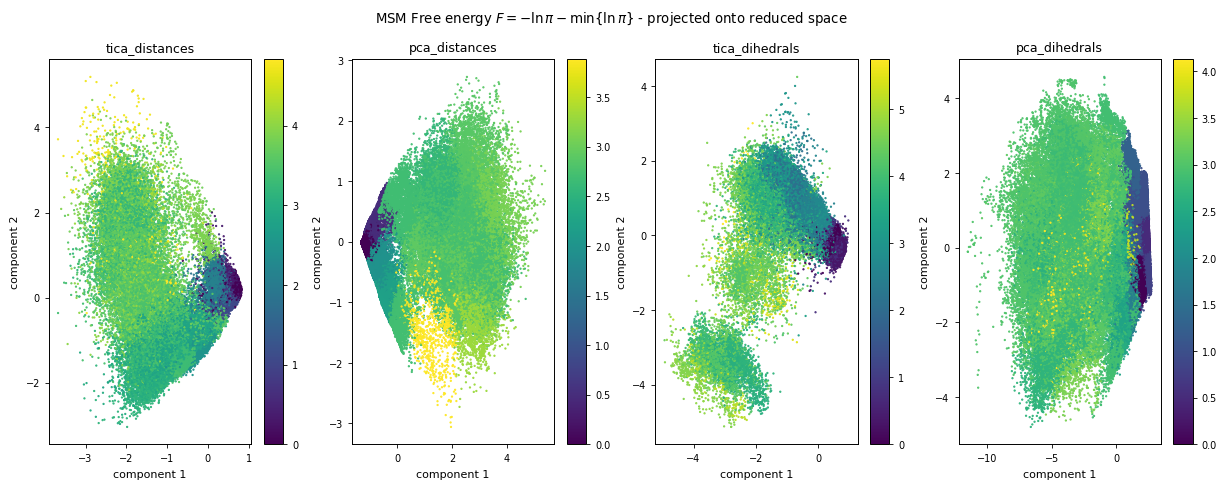

In [12]:
fig, axs = plt.subplots(nrows = 1, ncols = 4, figsize=(15, 5))


for i, name in enumerate(trajectories_labels):

    traj = micro_trajectory_dict[name]
    pi = msm_dict[name].stationary_distribution

    # transform  to free energy
    F = np.full_like(pi, np.nan)
    mask = pi > 0
    F[mask] = -np.log(pi[mask])
    F -= np.nanmin(F)

    z_values = np.full(len(traj), np.nan)
    mask = traj != -1
    z_values[mask] = F[traj[mask]]



    ax = axs[i]
    ax.scatter(trajectories[i][:, 0][::10], trajectories[i][:, 1][::10], c = z_values[::10], cmap = "viridis", s=0.4, alpha=1)
    plt.colorbar(ax.collections[0], ax=ax)
    ax.set_xlabel("component 1")
    ax.set_ylabel("component 2")
    ax.set_title(f"{name}")


plt.suptitle(r"MSM Free energy $F = -\ln{\pi} - \min\{{\ln{\pi}}\}$ - projected onto reduced space")   
plt.show()

---

## Spectral analysis of the microstate model

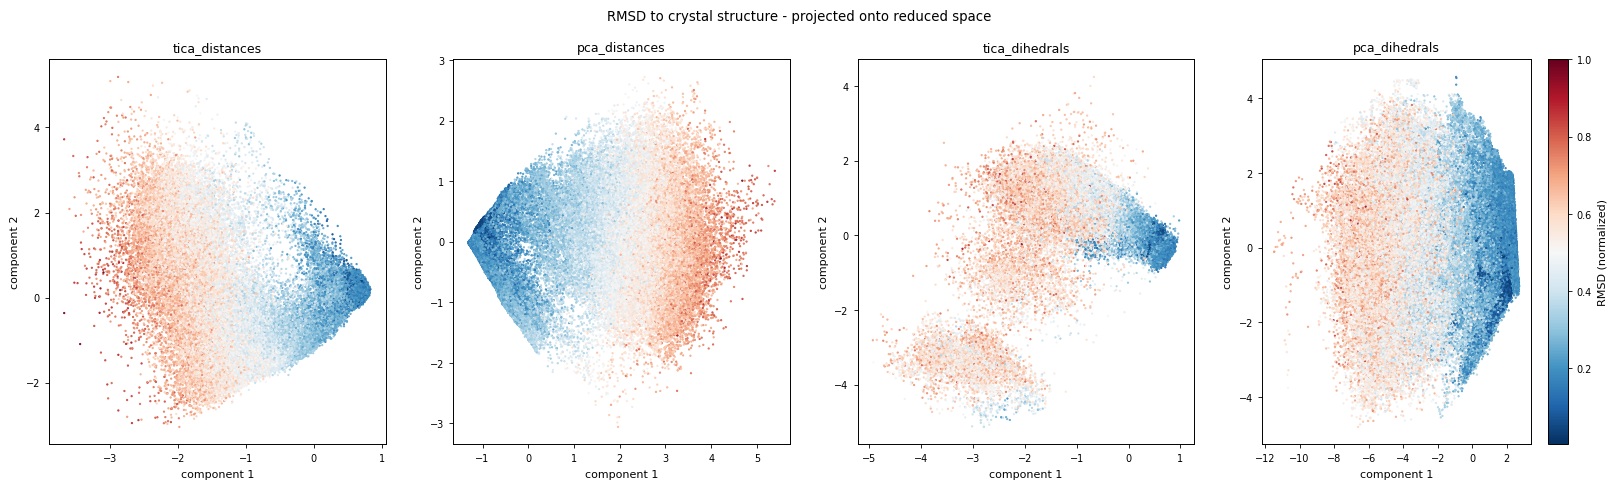

In [13]:
# Plot 1-Q for reference, and msm leading three eigenvectors
# (row stochastic convention -> look at the *right* eigenvectors)

# --------------------------------
# RMSD from crystal distances
# --------------------------------
crystal_dist = np.loadtxt(
    data_folder + "hp35.crystaldists",
    delimiter=" ",
    dtype=float
)

RMSD_timeseries = np.sqrt(np.mean(crystal_dist**2, axis=1))  # [nm]


z_timeseries = RMSD_timeseries - RMSD_timeseries.min()
z_timeseries = z_timeseries / z_timeseries.max() # now ranges from 0 to 1

fig, axs = plt.subplots(nrows = 1, ncols = 4, figsize=(20, 5))

for i, name in enumerate(trajectories_labels):
    ax = axs[i]
    ax.scatter(trajectories[i][:, 0][::10], trajectories[i][:, 1][::10], c = z_timeseries[::10], cmap = "RdBu_r", s=0.4, alpha=1)
    if i == len(trajectories_labels) - 1:
        plt.colorbar(ax.collections[0], ax=ax, label="RMSD (normalized)")
    #else:
    #    plt.colorbar(ax.collections[0], ax=ax)
    ax.set_xlabel("component 1")
    ax.set_ylabel("component 2")
    ax.set_title(f"{name}")

plt.suptitle(r"RMSD to crystal structure - projected onto reduced space")     
plt.show()

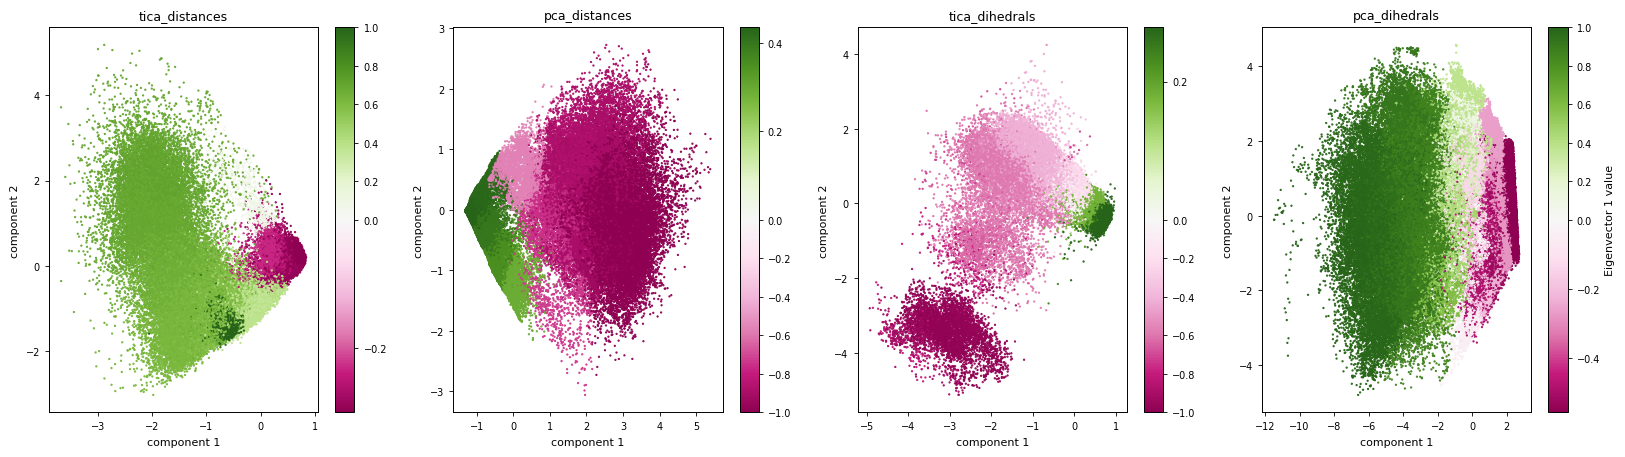

In [15]:
# Plotting the first eigenvector of the MSMs

eigvecs_to_plot = 1 # number of eigenvectors to plot
mode_index = 1 # eigenvector index: 0 = stationary, 1 = slowest, 2 = second slowest

fig, axs = plt.subplots(
    nrows=1,
    ncols=4,
    figsize=(20, 5 * eigvecs_to_plot),
)


for i, name in enumerate(trajectories_labels):
    msm = msm_dict[name]

    # ---------------------------------------
    # Weighted dynamical mode: left eigenvector
    # ---------------------------------------
    #L = msm.eigenvectors_left(k=mode_index + 1)[mode_index, :]
    #L_normalized = L / np.max(np.abs(L))

    # ---------------------------------------
    # Unweighted dynamical mode: right eigenvector
    # ---------------------------------------
    R = msm.eigenvectors_right(k=mode_index + 1)[:, mode_index]
    R_normalized = R / np.max(np.abs(R))


    traj = micro_trajectory_dict[name]
    # transform  to eigvec values
    z_values = np.full((len(traj)), np.nan)
    mask = traj != -1
    z_values[mask] = R_normalized[traj[mask]]
    #z_values[mask] = L_normalized[traj[mask], :eigvecs_to_plot]

    xy = trajectories[i]

    ax = axs[i]
    norm = TwoSlopeNorm(vcenter=0.0)
    
    ax.scatter(xy[:, 0][::10], xy[:, 1][::10], c = z_values[::10], norm = norm, cmap = "PiYG", s=0.4, alpha=1)
    if i == len(trajectories_labels) - 1:
        plt.colorbar(ax.collections[0], ax=ax, label=f"Eigenvector {mode_index} value")
    else:
        plt.colorbar(ax.collections[0], ax=ax)
    ax.set_xlabel("component 1")
    ax.set_ylabel("component 2")
    ax.set_title(f"{name}")    

Plot the second eigenvector, only for the tICA models

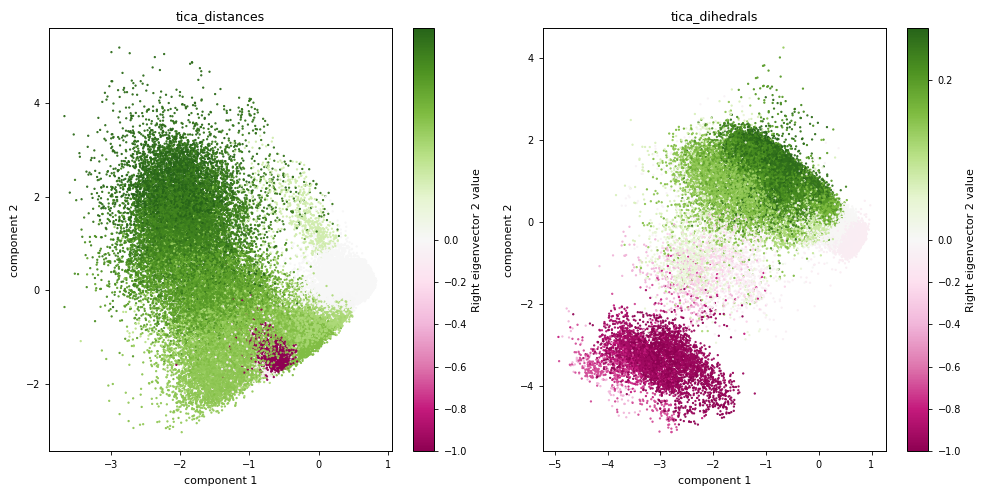

In [16]:
from matplotlib.colors import TwoSlopeNorm


mode_index = 2   # eigenvector index: 0 = stationary, 1 = slowest, 2 = second slowest
stride = 10


fig, axs = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(10, 5),
    squeeze=False
)

trajectories_labels_for_plot = ["tica_distances", "tica_dihedrals"]
trajectories_for_plot = [tica_distances, tica_dihedrals]


for i, name in enumerate(trajectories_labels_for_plot):
    msm = msm_dict[name]

    # ---------------------------------------
    # Weighted dynamical mode: left eigenvector
    # ---------------------------------------
    #L = msm.eigenvectors_left(k=mode_index + 1)[mode_index, :]
    #L_normalized = L / np.max(np.abs(L))

    # ---------------------------------------
    # Unweighted dynamical mode: right eigenvector
    # ---------------------------------------
    R = msm.eigenvectors_right(k=mode_index + 1)[:, mode_index]
    R_normalized = R / np.max(np.abs(R))

    traj = micro_trajectory_dict[name]

    # Map microstate eigenvector values back onto trajectory frames
    z_values = np.full(len(traj), np.nan)

    mask = traj != -1
    z_values[mask] = R_normalized[traj[mask]]

    xy = trajectories_for_plot[i]

    ax = axs[0, i]
    norm = TwoSlopeNorm(vcenter=0.0)

    sc = ax.scatter(
        xy[:, 0][::stride],
        xy[:, 1][::stride],
        c=z_values[::stride],
        norm=norm,
        cmap="PiYG",
        s=0.4,
        alpha=1.0,
    )

    plt.colorbar(sc, ax=ax, label=f"Right eigenvector {mode_index} value")

    ax.set_xlabel("component 1")
    ax.set_ylabel("component 2")
    ax.set_title(f"{name}")

plt.tight_layout()
plt.show()

---

Report-quality versions of the same plots

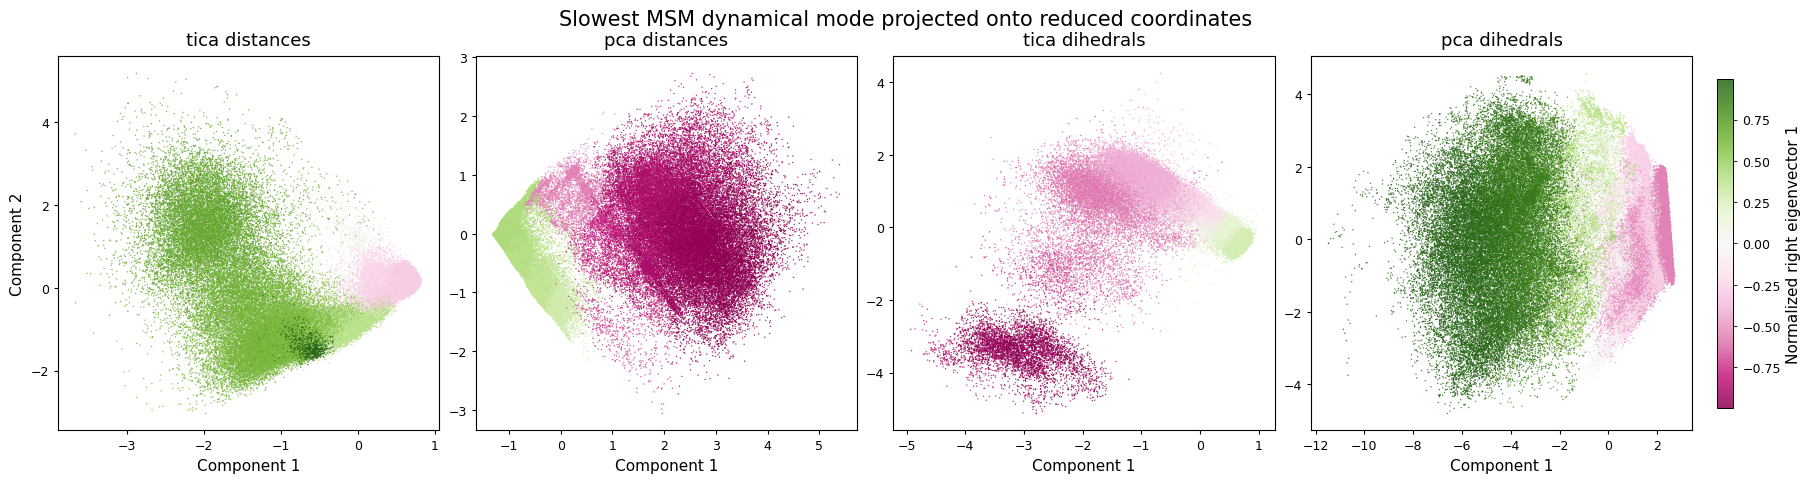

In [17]:
# -----------------------------
# Plotting the first non-stationary eigenvector of the MSMs
# -----------------------------

mode_index = 1   # 0 = stationary, 1 = slowest, 2 = second slowest
stride = 10

fig, axs = plt.subplots(
    nrows=1,
    ncols=4,
    figsize=(18, 4.5),
    sharex=False,
    sharey=False,
    constrained_layout=True,
)


# -----------------------------
# First pass: compute all z-values
# This allows a common color scale across all models.
# -----------------------------

z_values_dict = {}

for i, name in enumerate(trajectories_labels):
    msm = msm_dict[name]

    # ---------------------------------------
    # Unweighted dynamical mode: right eigenvector
    # ---------------------------------------
    R = msm.eigenvectors_right(k=mode_index + 1)[:, mode_index]
    R_normalized = R / np.max(np.abs(R))

    traj = micro_trajectory_dict[name]

    z_values = np.full(len(traj), np.nan)
    mask = traj != -1
    z_values[mask] = R_normalized[traj[mask]]

    z_values_dict[name] = z_values

# Common symmetric normalization
all_z = np.concatenate([
    z_values_dict[name][np.isfinite(z_values_dict[name])]
    for name in trajectories_labels
])

vmax = np.nanpercentile(np.abs(all_z), 99)
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

# -----------------------------
# Second pass: plot
# -----------------------------

for i, name in enumerate(trajectories_labels):
    ax = axs[i]

    xy = trajectories[i]
    z_values = z_values_dict[name]

    idx = np.arange(0, len(z_values), stride)
    finite = np.isfinite(z_values[idx])

    sc = ax.scatter(
        xy[idx, 0][finite],
        xy[idx, 1][finite],
        c=z_values[idx][finite],
        norm=norm,
        cmap="PiYG",
        s=1.0,
        alpha=0.85,
        linewidths=0,
        rasterized=True,
    )

    ax.set_title(
        name.replace("_", " "),
        fontsize=13,
        pad=8,
    )

    ax.set_xlabel("Component 1", fontsize=11)

    if i == 0:
        ax.set_ylabel("Component 2", fontsize=11)
    else:
        ax.set_ylabel("")

    ax.tick_params(
        axis="both",
        labelsize=9,
        direction="out",
        length=3,
        width=0.8,
    )

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)


# Shared colorbar
cbar = fig.colorbar(
    sc,
    ax=axs,
    location="right",
    shrink=0.88,
    pad=0.015,
)

cbar.set_label(
    f"Normalized right eigenvector {mode_index}",
    fontsize=11,
)
cbar.ax.tick_params(labelsize=9)

fig.suptitle(
    "Slowest MSM dynamical mode projected onto reduced coordinates",
    fontsize=15,
    y=1.04,
)

plt.savefig(
    f"../output_figures/msm_right_eigenvector_{mode_index}_projection.png",
    dpi=600,
    bbox_inches="tight",
)

plt.savefig(
    f"../output_figures/msm_right_eigenvector_{mode_index}_projection.pdf",
    bbox_inches="tight",
)
plt.show()

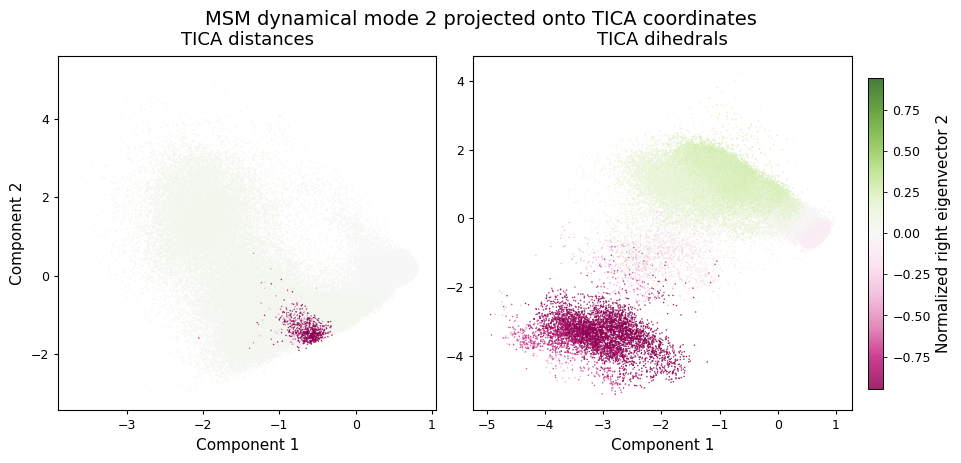

In [19]:
# -----------------------------
# Plotting the second non-stationary eigenvector of selected MSMs
# -----------------------------

mode_index = 2   # 0 = stationary, 1 = slowest, 2 = second slowest
stride = 10

trajectories_labels_for_plot = ["tica_distances", "tica_dihedrals"]
trajectories_for_plot = [tica_distances, tica_dihedrals]

pretty_labels = {
    "tica_distances": "TICA distances",
    "tica_dihedrals": "TICA dihedrals",
}

panel_labels = ["A", "B"]

fig, axs = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(9.5, 4.3),
    constrained_layout=True,
)

# -----------------------------
# First pass: compute z-values
# Needed for a common color scale.
# -----------------------------

z_values_dict = {}

for i, name in enumerate(trajectories_labels_for_plot):
    msm = msm_dict[name]

    # ---------------------------------------
    # Unweighted dynamical mode: right eigenvector
    # ---------------------------------------
    R = msm.eigenvectors_right(k=mode_index + 1)[:, mode_index]
    R_normalized = R / np.max(np.abs(R))

    traj = micro_trajectory_dict[name]

    z_values = np.full(len(traj), np.nan)
    mask = traj != -1
    z_values[mask] = R_normalized[traj[mask]]

    z_values_dict[name] = z_values

# Common symmetric normalization across both panels
all_z = np.concatenate([
    z_values_dict[name][np.isfinite(z_values_dict[name])]
    for name in trajectories_labels_for_plot
])

vmax = np.nanpercentile(np.abs(all_z), 99)
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

# -----------------------------
# Second pass: plot
# -----------------------------

for i, name in enumerate(trajectories_labels_for_plot):
    ax = axs[i]

    xy = trajectories_for_plot[i]
    z_values = z_values_dict[name]

    idx = np.arange(0, len(z_values), stride)
    finite = np.isfinite(z_values[idx])

    sc = ax.scatter(
        xy[idx, 0][finite],
        xy[idx, 1][finite],
        c=z_values[idx][finite],
        norm=norm,
        cmap="PiYG",
        s=1.2,
        alpha=0.85,
        linewidths=0,
        rasterized=True,
    )

    ax.set_title(
        pretty_labels.get(name, name.replace("_", " ")),
        fontsize=13,
        pad=8,
    )

    ax.set_xlabel("Component 1", fontsize=11)

    if i == 0:
        ax.set_ylabel("Component 2", fontsize=11)
    else:
        ax.set_ylabel("")

    ax.tick_params(
        axis="both",
        labelsize=9,
        direction="out",
        length=3,
        width=0.8,
    )

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)


# Shared colorbar
cbar = fig.colorbar(
    sc,
    ax=axs,
    location="right",
    shrink=0.88,
    pad=0.02,
)

cbar.set_label(
    f"Normalized right eigenvector {mode_index}",
    fontsize=11,
)
cbar.ax.tick_params(labelsize=9)

fig.suptitle(
    f"MSM dynamical mode {mode_index} projected onto TICA coordinates",
    fontsize=14,
    y=1.04,
)

plt.savefig(
    f"../output_figures/tica_right_eigenvector_{mode_index}_projection.png",
    dpi=600,
    bbox_inches="tight",
)

plt.savefig(
    f"../output_figures/tica_right_eigenvector_{mode_index}_projection.pdf",
    bbox_inches="tight",
)

plt.show()

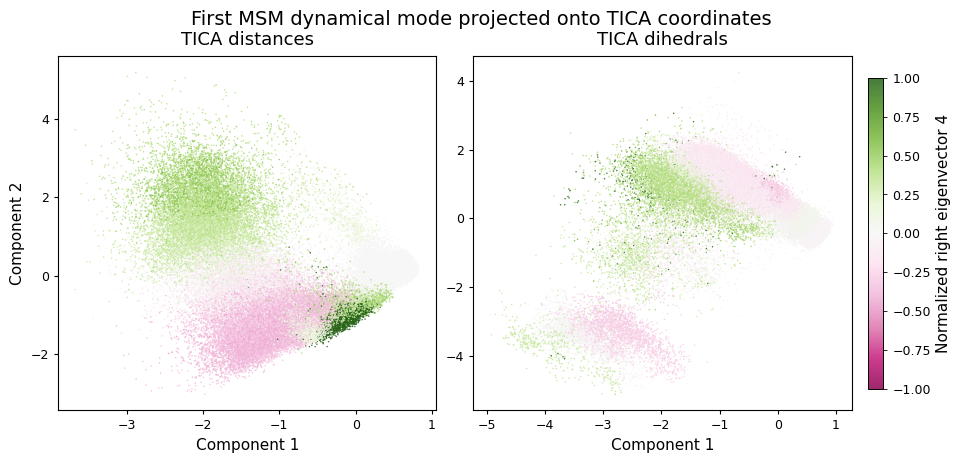

In [ ]:
# -----------------------------
# Plotting the second non-stationary eigenvector of selected MSMs
# -----------------------------

mode_index = 1   # 0 = stationary, 1 = slowest, 2 = second slowest
stride = 10

trajectories_labels_for_plot = ["tica_distances", "tica_dihedrals"]
trajectories_for_plot = [tica_distances, tica_dihedrals]

pretty_labels = {
    "tica_distances": "TICA distances",
    "tica_dihedrals": "TICA dihedrals",
}

panel_labels = ["A", "B"]

fig, axs = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(9.5, 4.3),
    constrained_layout=True,
)

# -----------------------------
# First pass: compute z-values
# Needed for a common color scale.
# -----------------------------

z_values_dict = {}

for i, name in enumerate(trajectories_labels_for_plot):
    msm = msm_dict[name]

    # ---------------------------------------
    # Unweighted dynamical mode: right eigenvector
    # ---------------------------------------
    R = msm.eigenvectors_right(k=mode_index + 1)[:, mode_index]
    R_normalized = R / np.max(np.abs(R))

    traj = micro_trajectory_dict[name]

    z_values = np.full(len(traj), np.nan)
    mask = traj != -1
    z_values[mask] = R_normalized[traj[mask]]

    z_values_dict[name] = z_values

# Common symmetric normalization across both panels
all_z = np.concatenate([
    z_values_dict[name][np.isfinite(z_values_dict[name])]
    for name in trajectories_labels_for_plot
])

vmax = np.nanpercentile(np.abs(all_z), 99)
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

# -----------------------------
# Second pass: plot
# -----------------------------

for i, name in enumerate(trajectories_labels_for_plot):
    ax = axs[i]

    xy = trajectories_for_plot[i]
    z_values = z_values_dict[name]

    idx = np.arange(0, len(z_values), stride)
    finite = np.isfinite(z_values[idx])

    sc = ax.scatter(
        xy[idx, 0][finite],
        xy[idx, 1][finite],
        c=z_values[idx][finite],
        norm=norm,
        cmap="PiYG",
        s=1.2,
        alpha=0.85,
        linewidths=0,
        rasterized=True,
    )

    ax.set_title(
        pretty_labels.get(name, name.replace("_", " ")),
        fontsize=13,
        pad=8,
    )

    ax.set_xlabel("Component 1", fontsize=11)

    if i == 0:
        ax.set_ylabel("Component 2", fontsize=11)
    else:
        ax.set_ylabel("")

    ax.tick_params(
        axis="both",
        labelsize=9,
        direction="out",
        length=3,
        width=0.8,
    )

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)


# Shared colorbar
cbar = fig.colorbar(
    sc,
    ax=axs,
    location="right",
    shrink=0.88,
    pad=0.02,
)

cbar.set_label(
    f"Normalized right eigenvector {mode_index}",
    fontsize=11,
)
cbar.ax.tick_params(labelsize=9)

fig.suptitle(
    "First MSM dynamical mode projected onto TICA coordinates",
    fontsize=14,
    y=1.04,
)

plt.savefig(
    f"../output_figures/tica_right_eigenvector_{mode_index}_projection.png",
    dpi=600,
    bbox_inches="tight",
)

plt.savefig(
    f"../output_figures/tica_right_eigenvector_{mode_index}_projection.pdf",
    bbox_inches="tight",
)

plt.show()